# ============================================================
# CAPSTONE PROJECT
# NOTEBOOK 11: FINAL PREDICTION PIPELINE
# ============================================================
# Purpose:
# This notebook implements the final genre prediction pipeline
# for a new audio file using the trained structured model,
# the improved audio CNN, and the hybrid fusion weights found
# in Notebook 10.
#
# The goal is to:
# 1. Load a new audio file
# 2. Extract a Mel spectrogram for the CNN branch
# 3. Extract engineered audio features for the structured branch
# 4. Run both trained models
# 5. Fuse their probabilities using the best hybrid weights
# 6. Return the predicted genre and confidence scores
# ============================================================

In [1]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import os
import joblib
import numpy as np
import pandas as pd
import librosa
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import kurtosis, skew

In [2]:
# ============================================================
# 2. LOAD SAVED MODELS, LABELS, AND FUSION SETTINGS
# ============================================================

structured_model = joblib.load("../models/best_structured_model.joblib")
cnn_model = tf.keras.models.load_model("../models/improved_audio_cnn.keras")

structured_feature_columns = np.load(
    "../data/processed/structured_feature_columns.npy",
    allow_pickle=True
)

class_names = np.load(
    "../data/processed/structured_label_classes.npy",
    allow_pickle=True
)

# Best fusion weights from Notebook 10
STRUCTURED_WEIGHT = 0.6
CNN_WEIGHT = 0.4

print("Loaded structured model.")
print("Loaded CNN model.")
print("Loaded class names:", class_names)
print("Fusion weights -> Structured:", STRUCTURED_WEIGHT, "| CNN:", CNN_WEIGHT)

Loaded structured model.
Loaded CNN model.
Loaded class names: ['Classical' 'Electronic' 'Experimental' 'Folk' 'Hip-Hop' 'Instrumental'
 'Pop' 'Rock']
Fusion weights -> Structured: 0.6 | CNN: 0.4


In [3]:
# ============================================================
# 3. HELPER FUNCTION: SAFE STATISTICS
# ============================================================

def safe_kurtosis(x):
    try:
        value = kurtosis(x, fisher=True, bias=False, nan_policy="omit")
        if np.isnan(value):
            return 0.0
        return float(value)
    except:
        return 0.0

def safe_skew(x):
    try:
        value = skew(x, bias=False, nan_policy="omit")
        if np.isnan(value):
            return 0.0
        return float(value)
    except:
        return 0.0

def compute_summary_stats(feature_matrix, feature_name):
    """
    feature_matrix shape should be:
    (n_coefficients, n_frames)
    or
    (n_frames,) which will be converted to (1, n_frames)
    """
    if feature_matrix.ndim == 1:
        feature_matrix = feature_matrix.reshape(1, -1)

    summary = {}

    for i in range(feature_matrix.shape[0]):
        values = np.asarray(feature_matrix[i], dtype=float)

        summary[f"{feature_name}_kurtosis_{i+1:02d}"] = safe_kurtosis(values)
        summary[f"{feature_name}_max_{i+1:02d}"] = float(np.nanmax(values))
        summary[f"{feature_name}_mean_{i+1:02d}"] = float(np.nanmean(values))
        summary[f"{feature_name}_median_{i+1:02d}"] = float(np.nanmedian(values))
        summary[f"{feature_name}_min_{i+1:02d}"] = float(np.nanmin(values))
        summary[f"{feature_name}_skew_{i+1:02d}"] = safe_skew(values)
        summary[f"{feature_name}_std_{i+1:02d}"] = float(np.nanstd(values))

    return summary

In [4]:
# ============================================================
# 4. EXTRACT STRUCTURED FEATURES FROM A NEW AUDIO FILE
# ============================================================

def extract_structured_features(audio_path, sr=22050, duration=30):
    """
    Extracts engineered audio features that match the main
    feature families used in features.csv:
    chroma_cens, chroma_cqt, chroma_stft, mfcc, rmse,
    spectral_bandwidth, spectral_centroid, spectral_contrast,
    spectral_rolloff, tonnetz, zcr
    """

    y, sr = librosa.load(audio_path, sr=sr, duration=duration)

    # Harmonic component for tonnetz
    y_harmonic = librosa.effects.harmonic(y)

    feature_dict = {}

    # Chroma features
    chroma_stft = librosa.feature.chroma_stft(y=y, sr=sr)
    chroma_cqt = librosa.feature.chroma_cqt(y=y, sr=sr)
    chroma_cens = librosa.feature.chroma_cens(y=y, sr=sr)

    feature_dict.update(compute_summary_stats(chroma_stft, "chroma_stft"))
    feature_dict.update(compute_summary_stats(chroma_cqt, "chroma_cqt"))
    feature_dict.update(compute_summary_stats(chroma_cens, "chroma_cens"))

    # MFCCs
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
    feature_dict.update(compute_summary_stats(mfcc, "mfcc"))

    # RMSE
    rmse = librosa.feature.rms(y=y)
    feature_dict.update(compute_summary_stats(rmse, "rmse"))

    # Spectral features
    spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    spectral_bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    spectral_contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
    spectral_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)

    feature_dict.update(compute_summary_stats(spectral_centroid, "spectral_centroid"))
    feature_dict.update(compute_summary_stats(spectral_bandwidth, "spectral_bandwidth"))
    feature_dict.update(compute_summary_stats(spectral_contrast, "spectral_contrast"))
    feature_dict.update(compute_summary_stats(spectral_rolloff, "spectral_rolloff"))

    # Tonnetz
    tonnetz = librosa.feature.tonnetz(y=y_harmonic, sr=sr)
    feature_dict.update(compute_summary_stats(tonnetz, "tonnetz"))

    # Zero Crossing Rate
    zcr = librosa.feature.zero_crossing_rate(y)
    feature_dict.update(compute_summary_stats(zcr, "zcr"))

    # Convert to DataFrame and align to training column order
    feature_df = pd.DataFrame([feature_dict])

    # Reindex to exactly match the structured model training columns
    feature_df = feature_df.reindex(columns=structured_feature_columns, fill_value=0.0)

    # Safety cleanup
    feature_df = feature_df.replace([np.inf, -np.inf], np.nan).fillna(0.0)

    return feature_df

In [5]:
# ============================================================
# 5. EXTRACT MEL SPECTROGRAM FOR CNN INPUT
# ============================================================

def extract_mel_spectrogram(audio_path, sr=22050, duration=30, n_mels=128, target_width=1292):
    y, sr = librosa.load(audio_path, sr=sr, duration=duration)

    mel_spec = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_mels=n_mels
    )

    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

    if mel_spec_db.shape[1] < target_width:
        pad_width = target_width - mel_spec_db.shape[1]
        mel_spec_db = np.pad(
            mel_spec_db,
            ((0, 0), (0, pad_width)),
            mode="constant"
        )
    else:
        mel_spec_db = mel_spec_db[:, :target_width]

    return mel_spec_db

In [6]:
# ============================================================
# 6. PREDICTION FUNCTION FOR A NEW AUDIO FILE
# ============================================================

def predict_genre(audio_path, structured_weight=0.6, cnn_weight=0.4, show_plot=True):
    """
    Predict genre for a new audio file using:
    - structured engineered features
    - improved CNN spectrogram branch
    - hybrid fusion
    """

    # -------------------------------
    # Structured branch
    # -------------------------------
    structured_features = extract_structured_features(audio_path)
    structured_probs = structured_model.predict_proba(structured_features)[0]

    # -------------------------------
    # CNN branch
    # -------------------------------
    mel_spec = extract_mel_spectrogram(audio_path)
    cnn_input = mel_spec[np.newaxis, ..., np.newaxis]

    # Normalize like training data
    denom = np.max(np.abs(cnn_input))
    if denom != 0:
        cnn_input = cnn_input / denom

    cnn_probs = cnn_model.predict(cnn_input, verbose=0)[0]

    # -------------------------------
    # Hybrid fusion
    # -------------------------------
    hybrid_probs = (structured_weight * structured_probs) + (cnn_weight * cnn_probs)

    predicted_index = int(np.argmax(hybrid_probs))
    predicted_genre = class_names[predicted_index]

    # Top-3 genres
    top3_idx = np.argsort(hybrid_probs)[::-1][:3]
    top3_results = [(class_names[i], float(hybrid_probs[i])) for i in top3_idx]

    if show_plot:
        plt.figure(figsize=(10, 4))
        plt.bar(class_names, hybrid_probs)
        plt.xticks(rotation=45)
        plt.ylabel("Probability")
        plt.title("Hybrid Genre Prediction Probabilities")
        plt.tight_layout()
        plt.show()

    return {
        "predicted_genre": predicted_genre,
        "top3_predictions": top3_results,
        "structured_probs": structured_probs,
        "cnn_probs": cnn_probs,
        "hybrid_probs": hybrid_probs
    }

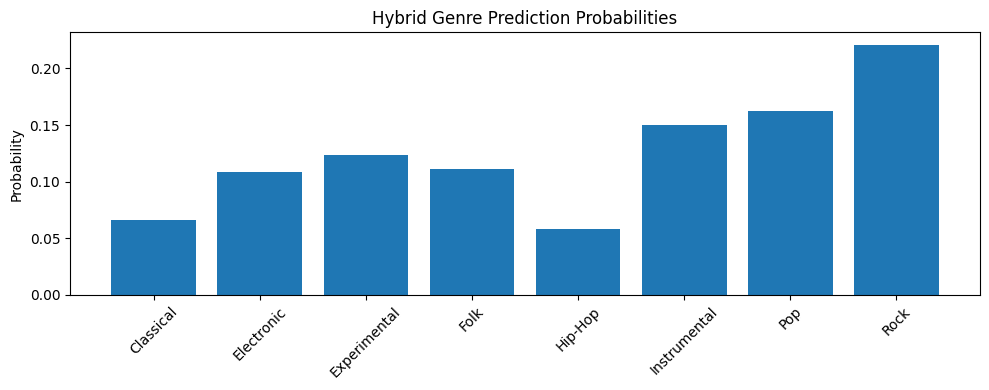

Predicted Genre: Rock

Top 3 Predictions:
Rock: 0.2209
Pop: 0.1623
Instrumental: 0.1497


In [13]:
# ============================================================
# 7. TEST THE FINAL PIPELINE ON A NEW AUDIO FILE
# ============================================================
# Replace this with the path to any audio file you want to test.

sample_audio_path = "../data/raw/audio/fma_large/000/000171.mp3"

results = predict_genre(
    sample_audio_path,
    structured_weight=STRUCTURED_WEIGHT,
    cnn_weight=CNN_WEIGHT,
    show_plot=True
)

print("Predicted Genre:", results["predicted_genre"])
print("\nTop 3 Predictions:")
for genre, prob in results["top3_predictions"]:
    print(f"{genre}: {prob:.4f}")

In [8]:
# ============================================================
# 8. VIEW STRUCTURED VS CNN VS HYBRID PROBABILITIES
# ============================================================

comparison_df = pd.DataFrame({
    "Genre": class_names,
    "Structured Probability": results["structured_probs"],
    "CNN Probability": results["cnn_probs"],
    "Hybrid Probability": results["hybrid_probs"]
}).sort_values("Hybrid Probability", ascending=False)

display(comparison_df)

,Genre,Structured Probability,CNN Probability,Hybrid Probability
7,Rock,0.098667,0.404169,0.220868
6,Pop,0.184917,0.128253,0.162251
5,Instrumental,0.150899,0.147919,0.149707
2,Experimental,0.115369,0.135904,0.123583
3,Folk,0.133482,0.077347,0.111028
1,Electronic,0.140375,0.060667,0.108492
0,Classical,0.100333,0.014560,0.066024
4,Hip-Hop,0.075958,0.031181,0.058048


In [9]:
# ============================================================
# 9. INTERPRETATION NOTES
# ============================================================

print("1. The final system accepts a new audio file as input.")
print("2. The structured branch extracts engineered audio descriptors from the file.")
print("3. The CNN branch converts the file into a Mel spectrogram and predicts genre probabilities.")
print("4. The two branches are combined using the best hybrid fusion weights found during evaluation.")
print("5. The final output is a genre prediction with confidence scores.")

1. The final system accepts a new audio file as input.
2. The structured branch extracts engineered audio descriptors from the file.
3. The CNN branch converts the file into a Mel spectrogram and predicts genre probabilities.
4. The two branches are combined using the best hybrid fusion weights found during evaluation.
5. The final output is a genre prediction with confidence scores.
